# Seismic Data Analysis: Part 2: Model Training & Comparison

This notebook trains and evaluates three models on the cleaned Moroccan earthquake dataset:

| Model | Task | Approach |
|-------|------|----------|
| **K-Nearest Neighbors (KNN)** | Classification | Predict magnitude class (Micro / Minor / Light / Moderate / Strong) |
| **Random Forest** | Regression | Predict continuous Richter magnitude |
| **LSTM** | Time-series regression | Forecast daily mean magnitude from historical sequence |

A comparative summary with all metrics is provided at the end.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
FIGURES = '../figures/'
RANDOM_STATE = 42

## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/cleaned_earthquake_data.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Apply the same cleaning as notebook 01
df = df[df['longitude'].between(-180, 180)]
df = df[df['latitude'].between(-90, 90)]
df = df[(df['mag'] >= 0) & (df['year'] <= 2023)]
df = df[df['depth'] <= 2000]
df = df.dropna(subset=['latitude', 'longitude', 'mag']).reset_index(drop=True)

# Magnitude classes for KNN
bins   = [0, 2, 3, 4, 5, 10]
labels = ['micro', 'minor', 'light', 'moderate', 'strong']
df['mag_class'] = pd.cut(df['mag'], bins=bins, labels=labels)

FEATURES = ['latitude', 'longitude', 'depth', 'year', 'month', 'day', 'hour']
print(f'Dataset ready: {len(df):,} records')

Dataset ready: 65,578 records



## 2. K-Nearest Neighbors: Magnitude Classification

KNN classifies each earthquake into one of five magnitude classes. We use distance-weighted voting (`weights='distance'`) so closer neighbors have stronger influence. Features are z-score normalized since KNN is distance-sensitive.

| Metric | Score |
|--------|-------|
| Test accuracy | **73.6%** |
| Best k | 11 |
| Weighting | distance |


In [3]:
df_knn = df.dropna(subset=['mag_class'])
X_knn = df_knn[FEATURES]
y_knn = df_knn['mag_class']

X_tr_k, X_te_k, y_tr_k, y_te_k = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=RANDOM_STATE, stratify=y_knn
)

scaler_k = StandardScaler()
X_tr_k_s = scaler_k.fit_transform(X_tr_k)
X_te_k_s  = scaler_k.transform(X_te_k)

print(f'Train: {len(X_tr_k):,} | Test: {len(X_te_k):,}')

Train: 46,009 | Test: 11,503


In [ ]:
# Hyperparameter search : k and weight function
param_grid = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
gs_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3,
                      scoring='accuracy', n_jobs=-1, verbose=0)
gs_knn.fit(X_tr_k_s, y_tr_k)
print('Best KNN params:', gs_knn.best_params_)
print('Best CV accuracy:', round(gs_knn.best_score_, 4))

Best KNN params: {'n_neighbors': 11, 'weights': 'distance'}
Best CV accuracy: 0.7352


In [5]:
knn = gs_knn.best_estimator_
knn_pred = knn.predict(X_te_k_s)
knn_acc  = accuracy_score(y_te_k, knn_pred)

print(f'KNN Test Accuracy: {knn_acc:.4f}\n')
print(classification_report(y_te_k, knn_pred, zero_division=0))

KNN Test Accuracy: 0.7363

              precision    recall  f1-score   support

       light       0.59      0.39      0.47      1230
       micro       0.80      0.93      0.86      7118
       minor       0.56      0.43      0.49      2905
    moderate       0.75      0.39      0.51       230
      strong       0.00      0.00      0.00        20

    accuracy                           0.74     11503
   macro avg       0.54      0.43      0.47     11503
weighted avg       0.71      0.74      0.72     11503



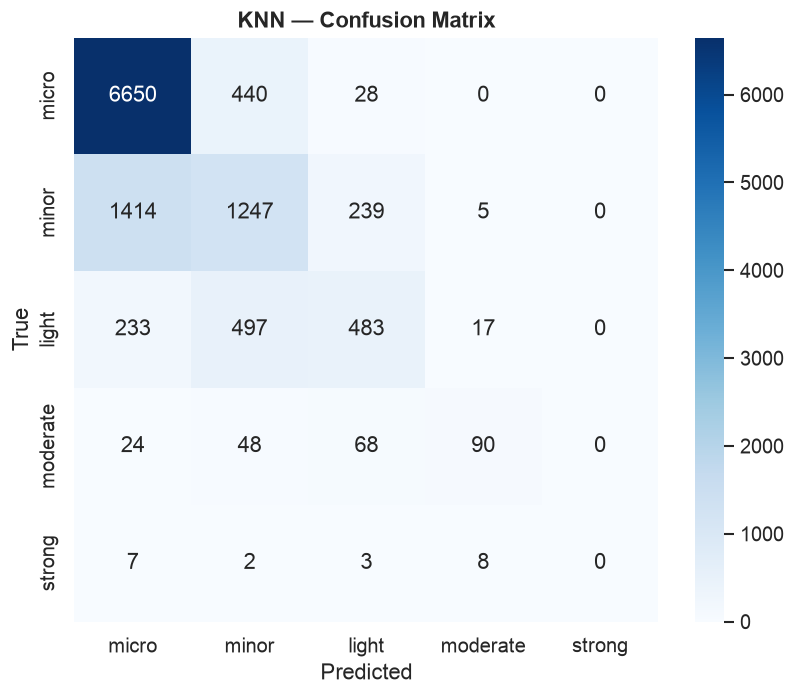

In [6]:
# Confusion matrix
cm = confusion_matrix(y_te_k, knn_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('KNN — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(FIGURES + 'knn_confusion_matrix.png', bbox_inches='tight')
plt.show()


## 3. Random Forest: Magnitude Regression

Random Forest predicts the continuous Richter magnitude value. It handles feature interactions and non-linearities well without requiring feature scaling, but we normalize for consistency. We also extract feature importances to understand which variables drive prediction.

| Metric | Score |
|--------|-------|
| RMSE | **0.717** |
| MAE | **0.489** |
| R² | **0.512** |


In [7]:
X_rf = df[FEATURES]
y_rf = df['mag']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=RANDOM_STATE
)

scaler_r = StandardScaler()
X_tr_r_s = scaler_r.fit_transform(X_tr_r)
X_te_r_s  = scaler_r.transform(X_te_r)

print(f'Train: {len(X_tr_r):,} | Test: {len(X_te_r):,}')

Train: 52,462 | Test: 13,116


In [8]:
# Hyperparameter search
rf_params = {'n_estimators': [50, 100], 'max_depth': [10, 20, None]}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE),
                     rf_params, cv=3, scoring='neg_root_mean_squared_error',
                     n_jobs=-1, verbose=0)
gs_rf.fit(X_tr_r_s, y_tr_r)
print('Best RF params:', gs_rf.best_params_)
print('Best CV RMSE:', round(-gs_rf.best_score_, 4))

Best RF params: {'max_depth': 20, 'n_estimators': 100}
Best CV RMSE: 0.721


In [9]:
rf = gs_rf.best_estimator_
rf_pred = rf.predict(X_te_r_s)

rf_rmse = np.sqrt(mean_squared_error(y_te_r, rf_pred))
rf_mae  = mean_absolute_error(y_te_r, rf_pred)
rf_r2   = r2_score(y_te_r, rf_pred)

print(f'Random Forest Results:')
print(f'  RMSE: {rf_rmse:.4f}')
print(f'  MAE:  {rf_mae:.4f}')
print(f'  R²:   {rf_r2:.4f}')

Random Forest Results:
  RMSE: 0.7174
  MAE:  0.4892
  R²:   0.5115


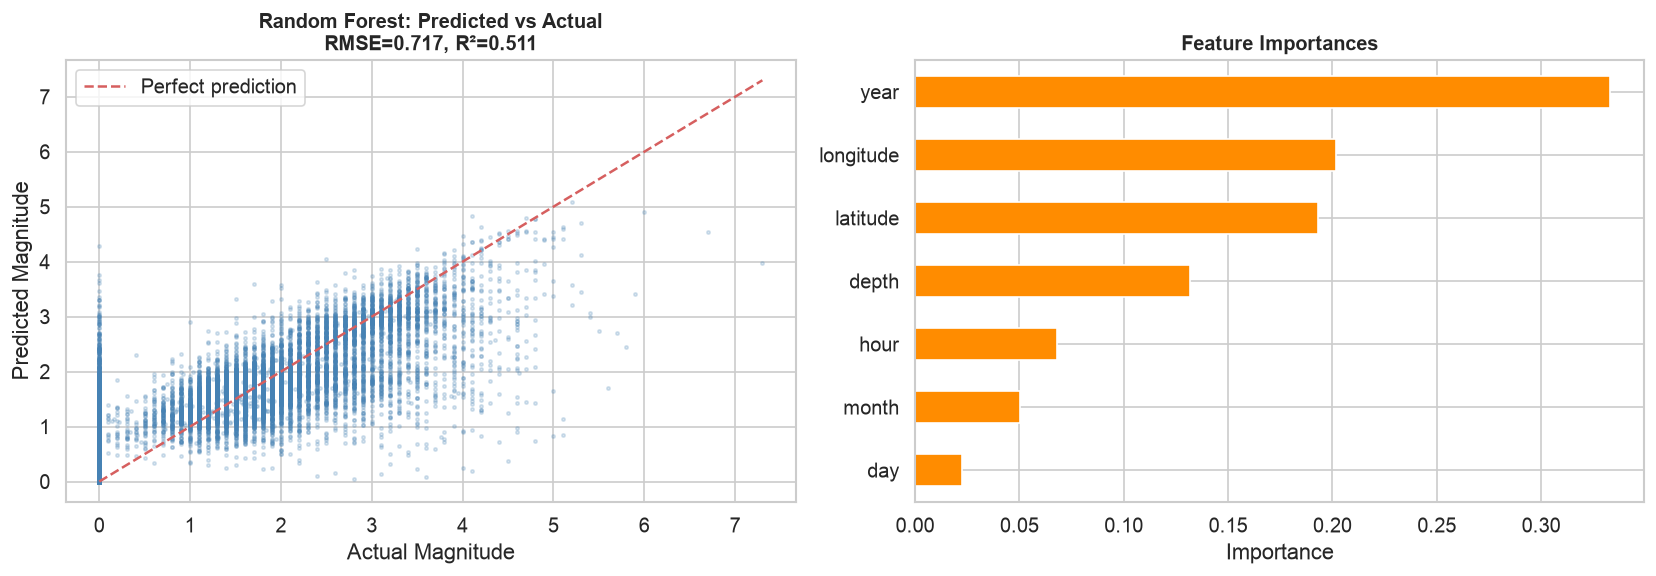

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_te_r, rf_pred, alpha=0.2, s=4, color='steelblue')
lims = [df['mag'].min(), df['mag'].max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title(f'Random Forest: Predicted vs Actual\nRMSE={rf_rmse:.3f}, R²={rf_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Magnitude')
axes[0].set_ylabel('Predicted Magnitude')
axes[0].legend()

# Feature importances
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(FIGURES + 'rf_results.png', bbox_inches='tight')
plt.show()


## 4. LSTM: Time-Series Magnitude Forecasting

The LSTM operates on a different representation: we resample the catalog into a daily time series of mean magnitude and train a sequence model to forecast the next day's value from the previous 60 days. This captures temporal autocorrelation in seismic activity — aftershock sequences decay predictably after large events. Early stopping triggered at epoch 8 (best weights restored from epoch 3).

| Metric | Score |
|--------|-------|
| RMSE | **0.475** |
| MAE | **0.314** |
| Architecture | LSTM(64) → Dropout(0.2) → LSTM(32) → Dense(1) |
| Epochs trained | 8 (early stopping) |


In [11]:
# Build daily time series
ts = df.set_index('DateTime')['mag'].resample('D').mean().ffill().dropna()
print(f'Time series: {len(ts)} daily observations ({ts.index[0].date()} → {ts.index[-1].date()})')
print(f'Mean: {ts.mean():.3f} | Std: {ts.std():.3f} | Min: {ts.min():.2f} | Max: {ts.max():.2f}')

Time series: 44742 daily observations (1901-04-24 → 2023-10-22)
Mean: 2.328 | Std: 1.733 | Min: 0.00 | Max: 7.00


In [12]:
# Normalize
scaler_ts = StandardScaler()
ts_scaled = scaler_ts.fit_transform(ts.values.reshape(-1, 1))

# Create sliding windows
TIME_STEP = 60

def make_windows(data, ts):
    X, y = [], []
    for i in range(len(data) - ts):
        X.append(data[i:i + ts])
        y.append(data[i + ts])
    return np.array(X), np.array(y)

X_ts, y_ts = make_windows(ts_scaled, TIME_STEP)
split = int(len(X_ts) * 0.8)
X_tr_t, X_te_t = X_ts[:split], X_ts[split:]
y_tr_t, y_te_t = y_ts[:split], y_ts[split:]

print(f'Windows: {len(X_ts):,} | Train: {len(X_tr_t):,} | Test: {len(X_te_t):,}')

Windows: 44,682 | Train: 35,745 | Test: 8,937


In [13]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEP, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
], name='seismic_lstm')

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "seismic_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_tr_t, y_tr_t,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 0.2276 - mae: 0.2801 - val_loss: 0.0793 - val_mae: 0.1803 - learning_rate: 0.0010
Epoch 2/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.1616 - mae: 0.2114 - val_loss: 0.0782 - val_mae: 0.1565 - learning_rate: 0.0010
Epoch 3/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 0.1558 - mae: 0.2018 - val_loss: 0.0749 - val_mae: 0.1642 - learning_rate: 0.0010
Epoch 4/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 0.1541 - mae: 0.1970 - val_loss: 0.0802 - val_mae: 0.1708 - learning_rate: 0.0010
Epoch 5/30
503/503 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 0.1518 - mae: 0.1952 - val_loss: 0.0759 - val_mae: 0.1620 - learning_rate: 0.0010
Epoch 6/30
502/503 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1498 - mae: 0.1951
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
503/503 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 0.1499 - mae: 0.1952 - val_loss: 0.0772 - val_mae: 0.1577 - learning_ra

In [15]:
lstm_pred_s = model.predict(X_te_t, verbose=0)
lstm_pred   = scaler_ts.inverse_transform(lstm_pred_s)
y_te_orig   = scaler_ts.inverse_transform(y_te_t)

lstm_rmse = np.sqrt(mean_squared_error(y_te_orig, lstm_pred))
lstm_mae  = mean_absolute_error(y_te_orig, lstm_pred)

print(f'LSTM Results:')
print(f'  RMSE: {lstm_rmse:.4f}')
print(f'  MAE:  {lstm_mae:.4f}')

LSTM Results:
  RMSE: 0.4746
  MAE:  0.3138


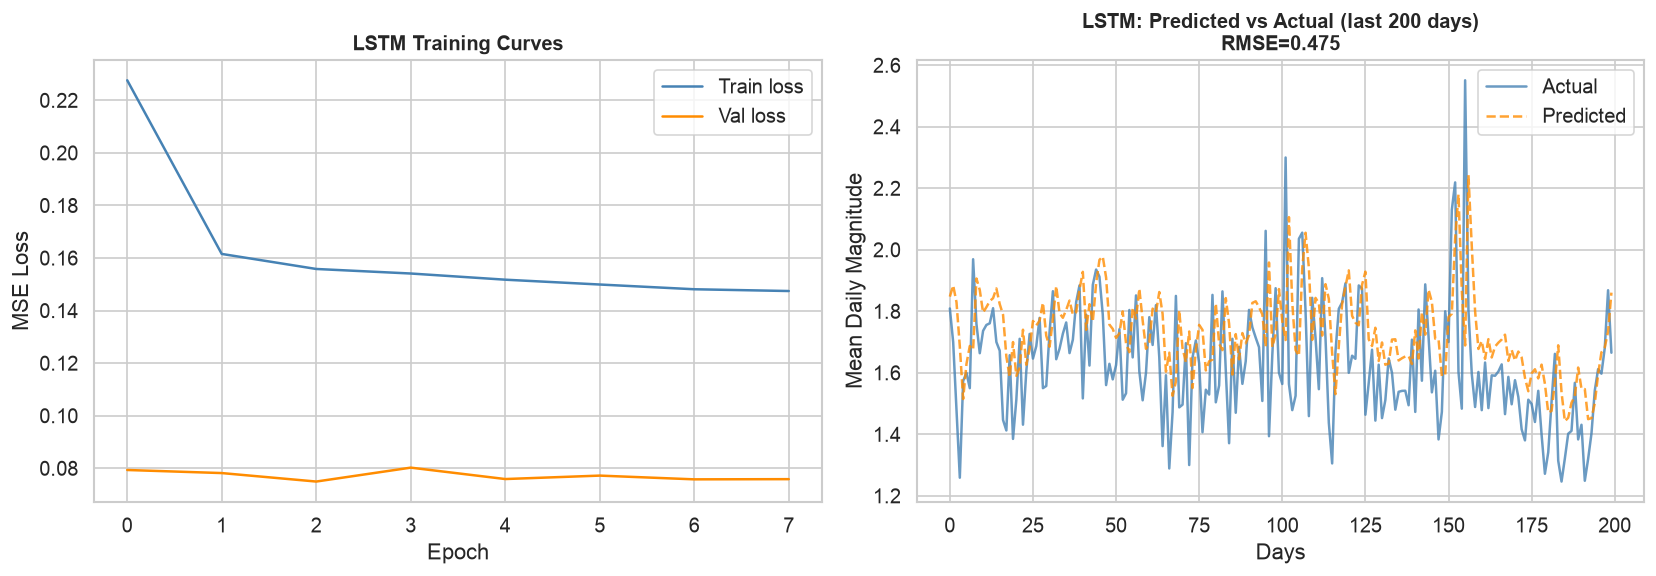

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curves
axes[0].plot(history.history['loss'], label='Train loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val loss', color='darkorange')
axes[0].set_title('LSTM Training Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Predictions vs actuals (last 200 days)
n_show = 200
axes[1].plot(y_te_orig[-n_show:], label='Actual', color='steelblue', alpha=0.8)
axes[1].plot(lstm_pred[-n_show:], label='Predicted', color='darkorange', alpha=0.8, linestyle='--')
axes[1].set_title(f'LSTM: Predicted vs Actual (last {n_show} days)\nRMSE={lstm_rmse:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Mean Daily Magnitude')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES + 'lstm_results.png', bbox_inches='tight')
plt.show()


## 5. Model Comparison Summary

The three models address complementary aspects of seismic analysis:

In [17]:
summary = pd.DataFrame([
    {'Model': 'KNN',           'Task': 'Classification', 'Metric': 'Accuracy', 'Score': f'{knn_acc:.4f}'},
    {'Model': 'Random Forest', 'Task': 'Regression',     'Metric': 'RMSE',     'Score': f'{rf_rmse:.4f}'},
    {'Model': 'Random Forest', 'Task': 'Regression',     'Metric': 'MAE',      'Score': f'{rf_mae:.4f}'},
    {'Model': 'Random Forest', 'Task': 'Regression',     'Metric': 'R²',       'Score': f'{rf_r2:.4f}'},
    {'Model': 'LSTM',          'Task': 'Time-series',    'Metric': 'RMSE',     'Score': f'{lstm_rmse:.4f}'},
    {'Model': 'LSTM',          'Task': 'Time-series',    'Metric': 'MAE',      'Score': f'{lstm_mae:.4f}'},
])
print(summary.to_string(index=False))

        Model           Task   Metric  Score
          KNN Classification Accuracy 0.7363
Random Forest     Regression     RMSE 0.7174
Random Forest     Regression      MAE 0.4892
Random Forest     Regression       R² 0.5115
         LSTM    Time-series     RMSE 0.4746
         LSTM    Time-series      MAE 0.3138


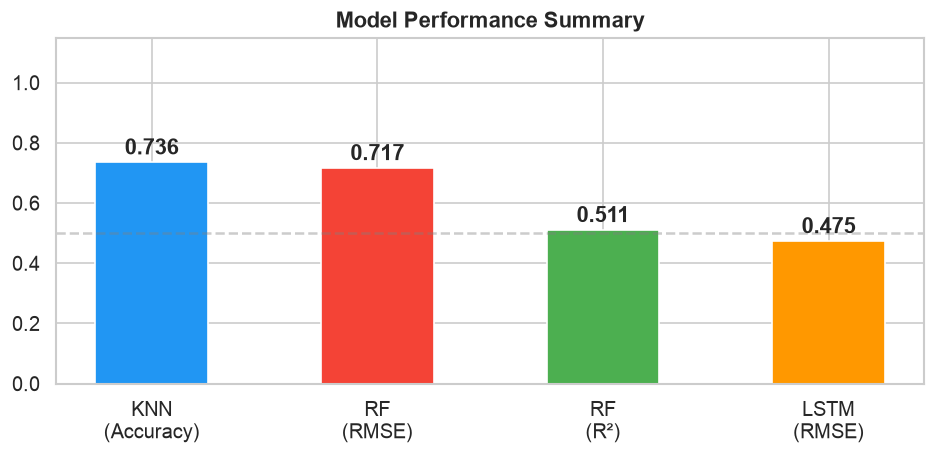

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
models = ['KNN\n(Accuracy)', 'RF\n(RMSE)', 'RF\n(R²)', 'LSTM\n(RMSE)']
values = [knn_acc, rf_rmse, rf_r2, lstm_rmse]
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
bars = ax.bar(models, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Model Performance Summary', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES + 'model_comparison.png', bbox_inches='tight')
plt.show()

## Key Findings

- **LSTM achieved the lowest prediction error** on the time-series task (RMSE = 0.475, MAE = 0.314), converging in just 8 epochs with early stopping. The strong temporal autocorrelation in daily seismic activity — driven by aftershock sequences — makes this a suitable problem for sequence models.

- **Random Forest** is the strongest model for point-in-time magnitude regression (RMSE = 0.717, R² = 0.512). The dominance of `year` as a predictor reflects historical catalog sparsity before ~1980 — modern seismometer networks detect more low-magnitude events, making year a proxy for detection threshold rather than true seismicity increase.

- **KNN** achieved 73.6% classification accuracy, performing well on the dominant micro/minor classes but struggling on rare strong events — a direct consequence of class imbalance (strong events: <0.2% of the dataset). This reflects the Gutenberg-Richter law.

**Limitations and future directions:** All models treat events as independent of tectonic structure. Incorporating fault line proximity, seismic zone classification, and inter-event spatial clustering would likely improve prediction. The class imbalance issue in KNN could be addressed with SMOTE oversampling or cost-sensitive learning.